In [1]:
#어제 같이 올렸는데 파일 2개가 누락되서 지금 다시 올립니다....죄송합니다.

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D, MaxPooling1D,
    LSTM,
    Dense, Dropout, Flatten
)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [14]:
# --- 1. 데이터 로드 및 전처리 ---

# 데이터셋이 압축 해제된 경로 (본인 환경에 맞게 수정)
# 예: './data/UCI HAR Dataset/'
DATASET_PATH = '/content/drive/MyDrive/UCI HAR Dataset/'

# 원시 신호 데이터를 로드하는 함수
def load_signal_data(split): # split = 'train' 또는 'test'
    # 9개 축의 파일 리스트
    signal_files = [
        f'body_acc_x_{split}.txt', f'body_acc_y_{split}.txt', f'body_acc_z_{split}.txt',
        f'body_gyro_x_{split}.txt', f'body_gyro_y_{split}.txt', f'body_gyro_z_{split}.txt',
        f'total_acc_x_{split}.txt', f'total_acc_y_{split}.txt', f'total_acc_z_{split}.txt'
    ]

    # 데이터를 담을 리스트
    signal_data = []

    # 9개 파일을 순서대로 읽어서 리스트에 추가
    for file_name in signal_files:
        file_path = f'{DATASET_PATH}{split}/Inertial Signals/{file_name}'
        # 공백으로 구분된 텍스트 파일을 로드
        df = pd.read_csv(file_path, delim_whitespace=True, header=None)
        # NumPy 배열로 변환하여 리스트에 추가
        signal_data.append(df.values)

    # (9, 샘플 수, 128) 형태의 리스트를 (샘플 수, 128, 9) 형태로 변환
    # np.stack을 사용해 3번째 축(특징 축)으로 쌓음
    X_data = np.stack(signal_data, axis=-1)

    return X_data

# 라벨 데이터를 로드하는 함수
def load_label_data(split): # split = 'train' 또는 'test'
    file_path = f'{DATASET_PATH}{split}/y_{split}.txt'
    df = pd.read_csv(file_path, header=None)

    # 라벨이 1부터 6까지이므로 0부터 5까지로 조정 (원-핫 인코딩을 위해)
    y_data = df.values - 1

    # 원-핫 인코딩 수행
    return to_categorical(y_data, num_classes=6)

# 데이터 로드 실행
print("데이터 로딩 시작...")
X_train = load_signal_data('train')
X_test = load_signal_data('test')
y_train = load_label_data('train')
y_test = load_label_data('test')

데이터 로딩 시작...


/tmp/ipython-input-3956007466.py:23: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, delim_whitespace=True, header=None)
/tmp/ipython-input-3956007466.py:23: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, delim_whitespace=True, header=None)
/tmp/ipython-input-3956007466.py:23: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, delim_whitespace=True, header=None)
/tmp/ipython-input-3956007466.py:23: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, delim_whitespace=True, header=None)
/tmp/ipython-input-3

In [15]:
n_timesteps = X_train.shape[1] # 128
n_features = X_train.shape[2]  # 9
n_classes = y_train.shape[1]   # 6

In [16]:
# --- 2. CNN + LSTM 모델 구축 (단순화 버전) ---

print("\n--- CNN-LSTM 모델 구축 (단순화 버전) ---")

model = Sequential()

# === CNN 부분 ===
# 💡 개선: 필터 개수를 64 -> 32로 줄임
model.add(Conv1D(filters=32, kernel_size=3, activation='relu',
               input_shape=(n_timesteps, n_features)))
# 💡 개선: Conv1D 레이어 하나 제거
# model.add(Conv1D(filters=64, kernel_size=3, activation='relu'))
model.add(MaxPooling1D(pool_size=2))
model.add(Dropout(0.5)) # (Dropout은 그대로 두거나 0.6으로 높여도 좋습니다)

# === LSTM 부분 ===
# 💡 개선: LSTM 유닛 수를 100 -> 64로 줄임
model.add(LSTM(64))
model.add(Dropout(0.5))

# === 분류기 부분 ===
# 💡 개선: Dense 유닛 수를 100 -> 64로 줄임
model.add(Dense(64, activation='relu'))
model.add(Dense(n_classes, activation='softmax'))

model.summary()

# (이후 3. 모델 컴파일 및 학습, 4. 모델 평가는 동일하게 진행)


--- CNN-LSTM 모델 구축 (단순화 버전) ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 126, 32)        │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 63, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 63, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,278 (118.27 KB)

 Trainable params: 30,278 (118.27 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
# --- 3. 모델 컴파일 및 학습 ---

print("\n--- 모델 컴파일 및 학습 시작 ---")

# 💡 개선: 학습이 불안정했던 문제를 해결하기 위해 학습률(learning_rate)을 낮춤
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)

model.compile(loss='categorical_crossentropy',
              optimizer=optimizer,
              metrics=['accuracy'])


--- 모델 컴파일 및 학습 시작 ---


In [18]:
early_stopping = EarlyStopping(monitor='val_loss',
                              patience=5,
                              restore_best_weights=True)

In [19]:
history = model.fit(X_train, y_train,
                    epochs=35,
                    batch_size=32,
                    validation_data=(X_test, y_test),
                    callbacks=[early_stopping])

Epoch 1/35
230/230 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.2313 - loss: 1.7585 - val_accuracy: 0.5368 - val_loss: 1.4219
Epoch 2/35
230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.5436 - loss: 1.1867 - val_accuracy: 0.6318 - val_loss: 0.8255
Epoch 3/35
230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.6552 - loss: 0.7444 - val_accuracy: 0.6162 - val_loss: 0.8103
Epoch 4/35
230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.6875 - loss: 0.6936 - val_accuracy: 0.6719 - val_loss: 0.7003
Epoch 5/35
230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7053 - loss: 0.6389 - val_accuracy: 0.6804 - val_loss: 0.6821
Epoch 6/35
230/230 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.7282 - loss: 0.5985 - val_accuracy: 0.6973 - val_loss: 0.6525
Epoch 7/35
230/230 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.7597 - loss: 0.5515 - val_accuracy: 0.7058 - val_loss: 0.6534
Epoch 8/35
230/230 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7667 - loss: 0.5229 - val_accuracy:

In [20]:
# --- 4. 모델 평가 ---

print("\n--- 모델 평가 ---")
# (EarlyStopping이 restore_best_weights=True이므로, 가장 성능이 좋았던 모델로 평가됨)
loss, accuracy = model.evaluate(X_test, y_test)
print(f'테스트 데이터 손실(Loss): {loss:.4f}')
print(f'테스트 데이터 정확도(Accuracy): {accuracy * 100:.2f} %')


--- 모델 평가 ---
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8351 - loss: 0.5611
테스트 데이터 손실(Loss): 0.5021
테스트 데이터 정확도(Accuracy): 85.78 %



--- 학습 커브 그리기 ---


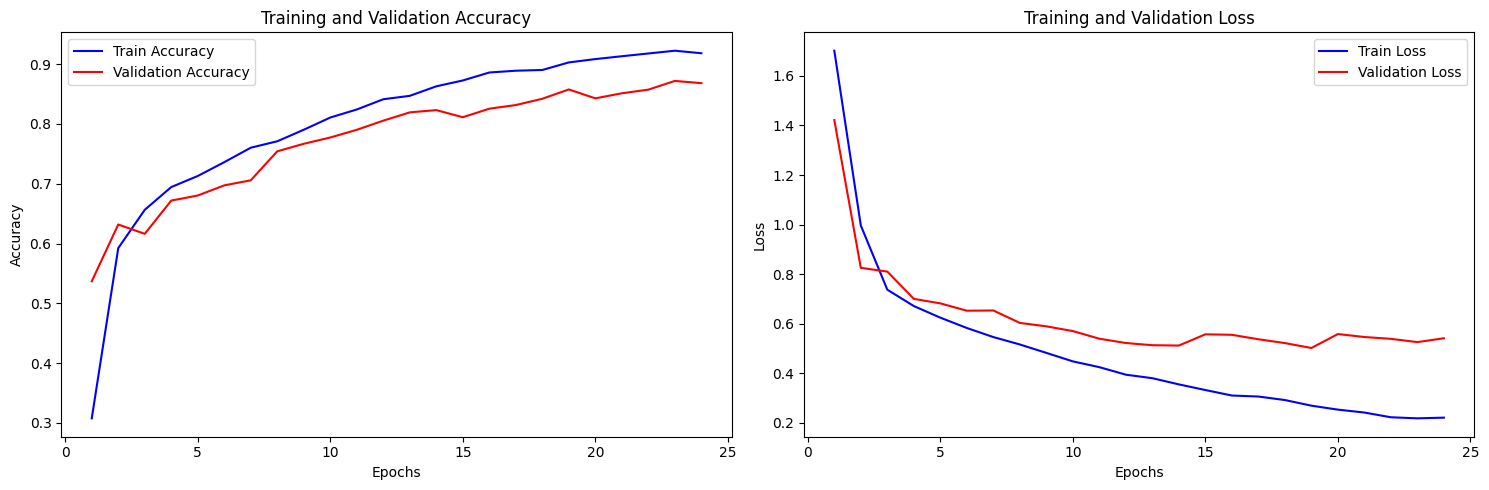

In [21]:
import matplotlib.pyplot as plt

# ----------------------------------------
# 1. 학습 커브 (정확도 및 손실)
# ----------------------------------------
print("\n--- 학습 커브 그리기 ---")

# history 객체에서 훈련 및 검증 정확도/손실 추출
# EarlyStopping으로 인해 epochs=30보다 적을 수 있습니다.
history_dict = history.history
train_acc = history_dict['accuracy']
val_acc = history_dict['val_accuracy']
train_loss = history_dict['loss']
val_loss = history_dict['val_loss']

# 에포크 수
epochs = range(1, len(train_acc) + 1)

# 1x2 크기의 서브플롯 생성
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# 📈 첫 번째 플롯: 정확도 (Accuracy)
ax1.plot(epochs, train_acc, 'b-', label='Train Accuracy')       # 훈련 정확도
ax1.plot(epochs, val_acc, 'r-', label='Validation Accuracy')  # 검증 정확도
ax1.set_title('Training and Validation Accuracy')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.legend()

# 📉 두 번째 플롯: 손실 (Loss)
ax2.plot(epochs, train_loss, 'b-', label='Train Loss')       # 훈련 손실
ax2.plot(epochs, val_loss, 'r-', label='Validation Loss')  # 검증 손실
ax2.set_title('Training and Validation Loss')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.legend()

# 플롯 표시
plt.tight_layout() # 플롯 간 간격 조절
plt.show()


--- 혼동 행렬 그리기 ---
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


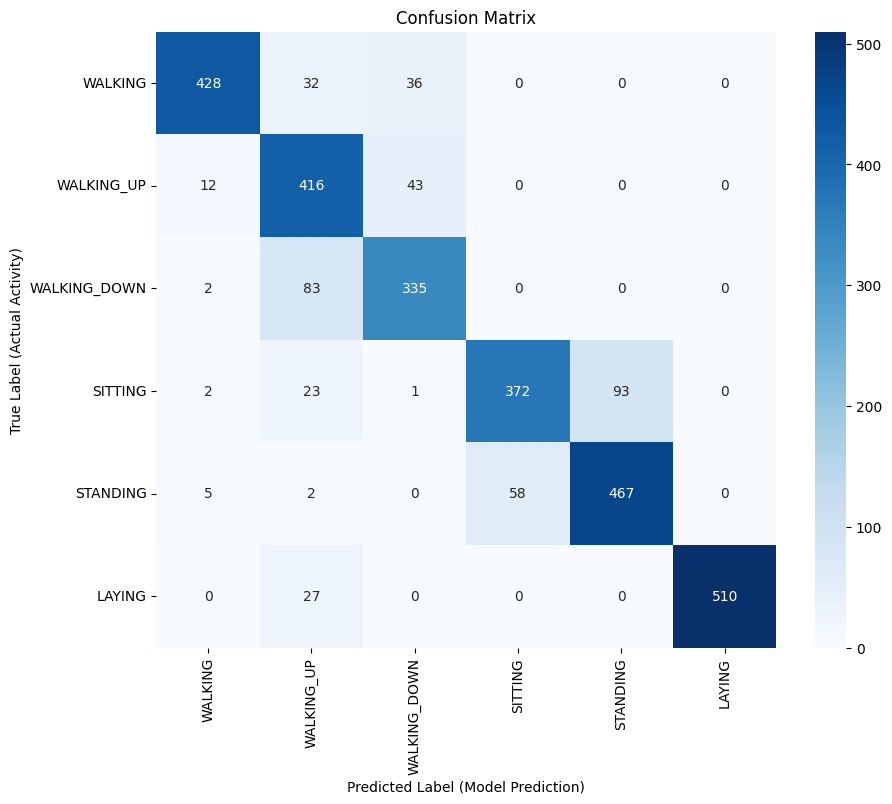

In [22]:
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix

# ----------------------------------------
# 2. 혼동 행렬 (Confusion Matrix)
# ----------------------------------------
print("\n--- 혼동 행렬 그리기 ---")

# 테스트 데이터(X_test)로 예측 수행
y_pred_probs = model.predict(X_test)

# 확률(probs)을 가장 높은 확률을 가진 클래스 인덱스로 변환
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# 원-핫 인코딩된 y_test를 다시 클래스 인덱스로 변환
y_true = np.argmax(y_test, axis=1)

# 혼동 행렬 계산
cm = confusion_matrix(y_true, y_pred_classes)

# 클래스(동작) 이름 정의 (UCI HAR Dataset 기준: 1~6)
# 0: WALKING, 1: WALKING_UPSTAIRS, 2: WALKING_DOWNSTAIRS, 3: SITTING, 4: STANDING, 5: LAYING
class_names = [
    'WALKING', 'WALKING_UP', 'WALKING_DOWN',
    'SITTING', 'STANDING', 'LAYING'
]

# Seaborn을 사용해 혼동 행렬 시각화
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)

plt.title('Confusion Matrix')
plt.ylabel('True Label (Actual Activity)')
plt.xlabel('Predicted Label (Model Prediction)')
plt.show()